# Sales & Profitability Intelligence: Python Analysis

In [55]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pyodbc
import seaborn as sns

In [56]:
conn = pyodbc.connect(
    r"DRIVER={ODBC Driver 17 for SQL Server};"
    r"SERVER=.\SQLEXPRESS;"                   
    r"DATABASE=SALES_PROFITABILITY_INTELLIGENCE;"
    r"Trusted_Connection=yes;"              
    r"Encrypt=no;"                       
)

In [57]:
df_customers = pd.read_sql("SELECT * FROM dbo.customers_clean", conn)
df_products = pd.read_sql("SELECT * FROM dbo.products", conn)
df_orders = pd.read_sql("SELECT * FROM dbo.orders", conn)
df_sales_customers = pd.read_sql("SELECT * FROM dbo.sales_customer", conn)

C:\Users\Asus\AppData\Local\Temp\ipykernel_7832\1558652417.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.read_sql("SELECT * FROM dbo.customers_clean", conn)
C:\Users\Asus\AppData\Local\Temp\ipykernel_7832\1558652417.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql("SELECT * FROM dbo.products", conn)
C:\Users\Asus\AppData\Local\Temp\ipykernel_7832\1558652417.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orders = pd.read_sql("SELECT * FROM dbo.orders", conn)
C:\Use

# DATA AUDIT


In [58]:
df_customers.shape

(25000, 10)

In [59]:
df_products.shape

(1175, 9)

In [60]:
df_orders.shape

(397569, 12)

In [61]:
df_sales_customers.shape

(138116, 46)

Insight: All four tables loaded with the expected row counts: 25,000 customers, 1,175 products, 397,569 order lines and 138,116 orders (about 2.9 lines per order). orders is the line grain and sales_customer is the order grain, so metrics must never be summed across both.

In [62]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                25000 non-null  str    
 1   customer_name              25000 non-null  str    
 2   customer_age               25000 non-null  int64  
 3   gender                     25000 non-null  str    
 4   customer_segment           25000 non-null  str    
 5   customer_city              25000 non-null  str    
 6   customer_state             25000 non-null  str    
 7   customer_country           25000 non-null  str    
 8   region                     25000 non-null  str    
 9   customer_acquisition_cost  25000 non-null  float64
dtypes: float64(1), int64(1), str(8)
memory usage: 1.9 MB


In [63]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1175 non-null   str    
 1   product_name         1175 non-null   str    
 2   product_category     1175 non-null   str    
 3   product_subcategory  1175 non-null   str    
 4   brand                1175 non-null   str    
 5   supplier             1175 non-null   str    
 6   unit_price           1175 non-null   float64
 7   product_cost         1175 non-null   float64
 8   product_rating       1175 non-null   float64
dtypes: float64(3), str(6)
memory usage: 82.7 KB


In [64]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 397569 entries, 0 to 397568
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             397569 non-null  str    
 1   product_id           397569 non-null  str    
 2   quantity             397569 non-null  int64  
 3   unit_price           397569 non-null  float64
 4   discount_percentage  397478 non-null  float64
 5   discount_amount      397569 non-null  float64
 6   gross_sales          397569 non-null  float64
 7   tax_amount           397569 non-null  float64
 8   shipping_cost        397569 non-null  float64
 9   net_sales            397569 non-null  float64
 10  product_cost         397569 non-null  float64
 11  profit               397569 non-null  float64
dtypes: float64(9), int64(1), str(2)
memory usage: 36.4 MB


In [65]:
df_sales_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  138116 non-null  str    
 1   order_date                138116 non-null  object 
 2   order_time                138116 non-null  object 
 3   order_status              138116 non-null  str    
 4   sales_channel             138116 non-null  str    
 5   customer_id               138116 non-null  str    
 6   customer_name             138116 non-null  str    
 7   customer_age              138116 non-null  int64  
 8   gender                    138116 non-null  str    
 9   customer_segment          138116 non-null  str    
 10  customer_type             138116 non-null  str    
 11  customer_city             138116 non-null  str    
 12  customer_state            138116 non-null  str    
 13  customer_country          138116 non-null  str    
 14 

In [66]:
df_customers.describe()

,customer_age,customer_acquisition_cost
count,25000.000000,25000.000000
mean,45.907840,42.159750
std,16.454286,21.692648
min,18.000000,5.010000
25%,32.000000,23.297500
50%,46.000000,41.980000
75%,60.000000,61.130001
max,74.000000,79.989998


In [67]:
df_orders.describe()

,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit
count,397569.000000,397569.000000,397478.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000
mean,2.118792,245.189134,0.147092,89.667873,519.013551,46.183642,8.409010,483.938328,267.520046,208.009273
std,1.196276,251.035135,0.129982,190.637796,676.800480,71.072019,6.777155,615.430188,394.773554,266.477677
min,1.000000,6.310000,0.000000,0.000000,6.310000,0.260000,0.000000,5.350000,1.970000,-1260.280029
25%,1.000000,74.360001,0.048201,5.940000,122.000000,9.560000,3.370000,124.279999,52.959999,53.730000
50%,2.000000,164.970001,0.124287,26.340000,280.190002,22.549999,5.870000,271.100006,127.099998,121.660004
75%,3.000000,310.790009,0.199513,86.029999,643.559998,52.340000,12.460000,595.239990,314.309998,259.660004
max,5.000000,1482.949951,0.600000,3857.669922,7414.750000,1482.949951,36.459999,8897.700195,4968.149902,4045.100098


In [68]:
df_products.describe()

,unit_price,product_cost,product_rating
count,1175.000000,1175.000000,1175.000000
mean,245.524400,126.536826,3.683064
std,251.267684,150.131834,0.698046
min,6.310000,1.970000,2.500000
25%,74.709999,29.565000,3.100000
50%,165.419998,74.540001,3.700000
75%,311.294998,153.044998,4.300000
max,1482.949951,993.630005,4.900000


In [69]:
df_sales_customers.describe()

,customer_age,customer_postal_code,delivery_days,estimated_delivery_days,customer_rating,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,customer_order_count
count,138116.000000,138116.000000,113559.000000,113559.000000,113559.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000
mean,45.862681,50210.889310,4.557772,4.298875,3.677015,103.991051,51.934128,5.615244,1375.384176,237.621614,122.462933,22.278080,1282.503575,708.903449,551.322046,45.065997,8971.639045,6.990559
std,16.467676,28569.767779,2.810012,2.594080,0.483672,115.175640,73.217692,3.371289,1291.009554,378.779459,140.939368,16.022739,1169.274669,730.044970,516.300936,13.120357,4430.506583,2.444166
min,18.000000,516.000000,0.000000,0.000000,1.600000,0.000000,0.000000,1.000000,6.310000,0.000000,0.340000,0.000000,5.800000,1.970000,-1281.589966,-59.549999,22.549999,1.000000
25%,32.000000,25509.000000,2.000000,2.000000,3.400000,17.000000,3.000000,3.000000,458.920013,26.327500,34.650002,9.820000,448.200012,207.667500,190.757496,38.880001,5713.569824,5.000000
50%,46.000000,50183.000000,4.000000,4.000000,3.700000,70.000000,25.000000,5.000000,995.729980,103.285000,77.010002,19.190001,950.760010,478.955002,408.395004,46.990002,8392.524902,7.000000
75%,60.000000,74898.000000,7.000000,6.000000,4.000000,151.000000,71.000000,8.000000,1871.199951,277.125000,156.199997,30.750000,1744.582458,953.762512,752.845016,53.770000,11651.030273,9.000000
max,74.000000,99950.000000,14.000000,10.000000,5.000000,1621.000000,1063.000000,24.000000,16051.190430,6759.020020,2091.520020,149.520004,16218.000000,9963.410156,7083.680176,77.589996,30268.439453,20.000000


Insight: Money columns (net_sales, profit, gross_sales) have long right tails, with 6,435 IQR outliers in net_sales. These are high-ticket and high-quantity orders rather than errors, so they are inspected but not removed.

In [70]:
df_customers.isna().sum()

customer_id                  0
customer_name                0
customer_age                 0
gender                       0
customer_segment             0
customer_city                0
customer_state               0
customer_country             0
region                       0
customer_acquisition_cost    0
dtype: int64

In [71]:
df_orders.isna().sum()

order_id                0
product_id              0
quantity                0
unit_price              0
discount_percentage    91
discount_amount         0
gross_sales             0
tax_amount              0
shipping_cost           0
net_sales               0
product_cost            0
profit                  0
dtype: int64

In [72]:
df_products.isna().sum()

product_id             0
product_name           0
product_category       0
product_subcategory    0
brand                  0
supplier               0
unit_price             0
product_cost           0
product_rating         0
dtype: int64

In [73]:
df_sales_customers.isna().sum()

order_id                         0
order_date                       0
order_time                       0
order_status                     0
sales_channel                    0
customer_id                      0
customer_name                    0
customer_age                     0
gender                           0
customer_segment                 0
customer_type                    0
customer_city                    0
customer_state                   0
customer_country                 0
region                           0
customer_postal_code             0
payment_method                   0
payment_status                   0
currency                         0
shipping_method                  0
warehouse                        0
delivery_days                24557
estimated_delivery_days      24557
delivery_status                  0
return_status               128654
return_reason               128654
customer_rating              24557
review_sentiment             24557
customer_review     

Insight: Core columns have no missing values. The only NULLs are structural and mean that an event did not happen: delivery_days and customer_rating (24,557, non-completed orders), return_reason (128,654, no return), campaign_name (83,233) and coupon_code (110,502). They are kept, not imputed. The single missing gender in customers was labelled Unknown in SQL.

In [74]:
df_customers.duplicated().sum()

np.int64(0)

In [75]:
df_orders.duplicated().sum()

np.int64(0)

In [76]:
df_products.duplicated().sum()

np.int64(0)

In [77]:
df_sales_customers.duplicated().sum()

np.int64(0)

In [78]:
df_customers.nunique()

customer_id                  25000
customer_name                21631
customer_age                    57
gender                           4
customer_segment                 4
customer_city                15555
customer_state                  38
customer_country                 7
region                           5
customer_acquisition_cost     7215
dtype: int64

In [79]:
df_orders.nunique()

order_id               138116
product_id               1175
quantity                    5
unit_price               1164
discount_percentage    341695
discount_amount         50505
gross_sales              5724
tax_amount              29348
shipping_cost            2699
net_sales              125944
product_cost             5516
profit                  78190
dtype: int64

In [80]:
df_products.nunique()

product_id             1175
product_name           1175
product_category         15
product_subcategory     117
brand                   144
supplier                 10
unit_price             1164
product_cost           1147
product_rating           25
dtype: int64

In [81]:
df_sales_customers.nunique()

order_id                    138116
order_date                    1826
order_time                   68991
order_status                     4
sales_channel                    4
customer_id                  24911
customer_name                21564
customer_age                    57
gender                           3
customer_segment                 4
customer_type                    3
customer_city                15516
customer_state                  38
customer_country                 7
region                           5
customer_postal_code         22117
payment_method                   7
payment_status                   4
currency                         7
shipping_method                  4
warehouse                       19
delivery_days                   15
estimated_delivery_days         11
delivery_status                  4
return_status                    1
return_reason                    8
customer_rating                 35
review_sentiment                 3
customer_review     

Insight: There are no fully duplicated rows. customer_id (25,000), product_id (1,175) and order_id (138,116) are unique keys. Only 21,631 distinct customer names exist for 25,000 customers, so customer_name must never be used as a join key.

In [82]:
df_customers.dtypes

customer_id                      str
customer_name                    str
customer_age                   int64
gender                           str
customer_segment                 str
customer_city                    str
customer_state                   str
customer_country                 str
region                           str
customer_acquisition_cost    float64
dtype: object

In [83]:
df_orders.dtypes

order_id                   str
product_id                 str
quantity                 int64
unit_price             float64
discount_percentage    float64
discount_amount        float64
gross_sales            float64
tax_amount             float64
shipping_cost          float64
net_sales              float64
product_cost           float64
profit                 float64
dtype: object

In [84]:
df_products.dtypes

product_id                 str
product_name               str
product_category           str
product_subcategory        str
brand                      str
supplier                   str
unit_price             float64
product_cost           float64
product_rating         float64
dtype: object

In [85]:
df_sales_customers.dtypes

order_id                        str
order_date                   object
order_time                   object
order_status                    str
sales_channel                   str
customer_id                     str
customer_name                   str
customer_age                  int64
gender                          str
customer_segment                str
customer_type                   str
customer_city                   str
customer_state                  str
customer_country                str
region                          str
customer_postal_code          int64
payment_method                  str
payment_status                  str
currency                        str
shipping_method                 str
warehouse                       str
delivery_days               float64
estimated_delivery_days     float64
delivery_status                 str
return_status                   str
return_reason                   str
customer_rating             float64
review_sentiment            

In [86]:
date_columns = [
    'order_date'
]
for col in date_columns:
    df_sales_customers['order_date'] = pd.to_datetime(df_sales_customers[col], errors='coerce')

In [87]:
df_sales_customers['order_date'].dtype

dtype('<M8[s]')

In [88]:
df_sales_customers['OrderDate_Year'] = df_sales_customers['order_date'].dt.year
df_sales_customers['OrderDate_Month'] = df_sales_customers['order_date'].dt.month
df_sales_customers['OrderDate_MonthName'] = df_sales_customers['order_date'].dt.month_name()
df_sales_customers['OrderDate_Quarter'] = df_sales_customers['order_date'].dt.quarter
df_sales_customers['OrderDate_DayOfWeek'] = df_sales_customers['order_date'].dt.day_name()

In [89]:
numeric_cols = df_sales_customers.select_dtypes(include=np.number).columns

numeric_cols

Index(['customer_age', 'customer_postal_code', 'delivery_days',
       'estimated_delivery_days', 'customer_rating', 'loyalty_points_earned',
       'loyalty_points_redeemed', 'quantity', 'gross_sales', 'discount_amount',
       'tax_amount', 'shipping_cost', 'net_sales', 'product_cost', 'profit',
       'profit_margin_percentage', 'customer_lifetime_value',
       'customer_order_count', 'OrderDate_Year', 'OrderDate_Month',
       'OrderDate_Quarter'],
      dtype='str')

In [90]:
df_sales_customers[df_sales_customers['quantity'] < 0]

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,OrderDate_Year,OrderDate_Month,OrderDate_MonthName,OrderDate_Quarter,OrderDate_DayOfWeek


In [91]:
df_sales_customers[df_sales_customers['gross_sales'] < 0]

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,OrderDate_Year,OrderDate_Month,OrderDate_MonthName,OrderDate_Quarter,OrderDate_DayOfWeek


In [92]:
df_sales_customers[df_sales_customers['net_sales'] < 0]

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,OrderDate_Year,OrderDate_Month,OrderDate_MonthName,OrderDate_Quarter,OrderDate_DayOfWeek


In [93]:
df_sales_customers[df_sales_customers['product_cost'] < 0]

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,OrderDate_Year,OrderDate_Month,OrderDate_MonthName,OrderDate_Quarter,OrderDate_DayOfWeek


In [94]:
df_products[df_products['unit_price'] < 0]

,product_id,product_name,product_category,product_subcategory,brand,supplier,unit_price,product_cost,product_rating


In [95]:
df_sales_customers[df_sales_customers['profit'] < 0]

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,OrderDate_Year,OrderDate_Month,OrderDate_MonthName,OrderDate_Quarter,OrderDate_DayOfWeek
174,ORD-937736,2025-12-24,15:51:07,Completed,Marketplace,CUST-003659,Kaitlin Richards,41,Male,Premium,...,-242.559998,-32.610001,5976.140137,True,6,2025,12,December,4,Wednesday
180,ORD-879372,2023-11-15,11:55:36,Completed,Social Media,CUST-022701,John Rodriguez,36,Male,Consumer,...,-213.350006,-14.100000,6944.660156,True,5,2023,11,November,4,Wednesday
208,ORD-810291,2021-12-09,19:23:24,Completed,Mobile App,CUST-013858,Jeff Richmond,49,Male,Premium,...,-277.260010,-16.790001,13756.349609,True,8,2021,12,December,4,Thursday
385,ORD-925513,2023-12-10,04:44:53,Completed,Social Media,CUST-024452,Nicholas Rose,50,Female,VIP,...,-368.850006,-9.820000,12258.830078,True,7,2023,12,December,4,Sunday
420,ORD-379518,2022-11-30,16:09:12,Completed,Mobile App,CUST-006469,Mary Johnston,57,Female,Consumer,...,-21.830000,-1.390000,8354.660156,True,5,2022,11,November,4,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137505,ORD-783112,2021-11-23,18:46:31,Completed,Website,CUST-010625,Sierra Hudson,41,Male,VIP,...,-228.509995,-6.050000,9994.780273,True,8,2021,11,November,4,Tuesday
137642,ORD-562309,2022-11-22,10:37:24,Completed,Mobile App,CUST-022893,Terri Duffy,42,Male,Premium,...,-32.430000,-1.720000,11143.200195,True,9,2022,11,November,4,Tuesday
137821,ORD-197962,2023-11-15,01:14:18,Completed,Mobile App,CUST-013262,Patrick Phillips,58,Male,Premium,...,-149.490005,-5.100000,10975.679688,True,8,2023,11,November,4,Wednesday
137937,ORD-539211,2021-11-07,08:04:40,Completed,Website,CUST-010007,Ashley Lee,59,Male,Consumer,...,-1.250000,-0.110000,4148.109863,True,6,2021,11,November,4,Sunday


Insight: No negative quantities, prices, costs or sales exist. The 1,296 orders with negative profit are a business finding caused by deep discounts, not a data error, and are analysed in section 7.

# Categorical columns

In [96]:
categorical_cols = df_customers.select_dtypes(include='object').columns

categorical_cols

C:\Users\Asus\AppData\Local\Temp\ipykernel_7832\1149411942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_customers.select_dtypes(include='object').columns


Index(['customer_id', 'customer_name', 'gender', 'customer_segment',
       'customer_city', 'customer_state', 'customer_country', 'region'],
      dtype='str')

In [97]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_customers[col].nunique())
    print(df_customers[col].value_counts(dropna=False).head(10))


--- customer_id ---
25000
customer_id
CUST-000001    1
CUST-000002    1
CUST-000003    1
CUST-000004    1
CUST-000005    1
CUST-000006    1
CUST-000007    1
CUST-000008    1
CUST-000009    1
CUST-000010    1
Name: count, dtype: int64

--- customer_name ---
21631
customer_name
John Smith          17
Michael Smith       15
James Smith         12
Jennifer Smith      11
Michael Johnson     11
David Smith         10
Michael Williams    10
David Brown          9
Lisa Jones           9
Brian Johnson        9
Name: count, dtype: int64

--- gender ---
4
gender
Female        12047
Male          11976
Non-Binary      976
Unknown           1
Name: count, dtype: int64

--- customer_segment ---
4
customer_segment
Consumer    13638
Premium      6301
VIP          2542
Business     2519
Name: count, dtype: int64

--- customer_city ---
15555
customer_city
South Michael       30
Lake Michael        30
East Michael        23
Port Michael        21
South James         20
New David           19
New Robert 

Insight: The customer base is 59.7% USA (14,925 of 25,000) across 7 countries and 5 regions, led by South (7,996, 32%). Segments are Consumer 54.6%, Premium 25.2%, VIP 10.2% and Business 10.1%. Customer counts are therefore a main driver of regional revenue.

In [98]:
categorical_cols_orders = df_orders.select_dtypes(include='object').columns

categorical_cols_orders

C:\Users\Asus\AppData\Local\Temp\ipykernel_7832\1066019295.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_orders = df_orders.select_dtypes(include='object').columns


Index(['order_id', 'product_id'], dtype='str')

In [99]:
for col in categorical_cols_orders:
    print(f"\n--- {col} ---")
    print(df_orders[col].nunique())
    print(df_orders[col].value_counts(dropna=False).head(10))


--- order_id ---
138116
order_id
ORD-688687    18
ORD-139538    17
ORD-310559    14
ORD-344946    14
ORD-821820    14
ORD-635314    14
ORD-926251    14
ORD-721206    14
ORD-945812    14
ORD-948179    13
Name: count, dtype: int64

--- product_id ---
1175
product_id
PROD-000839    414
PROD-000003    395
PROD-000449    393
PROD-000734    390
PROD-000584    389
PROD-000640    389
PROD-000694    387
PROD-000637    385
PROD-000241    384
PROD-000375    384
Name: count, dtype: int64


Insight: An order has up to 18 lines. The most frequent product (PROD-000839) appears in only 414 of 397,569 lines (0.1%), so demand is spread across the catalog with no single dominant item.

In [100]:
categorical_cols_products = df_products.select_dtypes(include='object').columns

categorical_cols_products

C:\Users\Asus\AppData\Local\Temp\ipykernel_7832\3360603605.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_products = df_products.select_dtypes(include='object').columns


Index(['product_id', 'product_name', 'product_category', 'product_subcategory',
       'brand', 'supplier'],
      dtype='str')

In [101]:
for col in categorical_cols_products:
    print(f"\n--- {col} ---")
    print(df_products[col].nunique())
    print(df_products[col].value_counts(dropna=False).head(10))


--- product_id ---
1175
product_id
PROD-000001    1
PROD-000002    1
PROD-000003    1
PROD-000004    1
PROD-000005    1
PROD-000006    1
PROD-000007    1
PROD-000008    1
PROD-000009    1
PROD-000010    1
Name: count, dtype: int64

--- product_name ---
1175
product_name
Apple Sharable bifurcated algorithm Smartphones               1
Google User-centric even-keeled encryption Smartphones        1
LG Face-to-face client-driven support Smartphones             1
Sony Customer-focused systematic support Smartphones          1
OnePlus Quality-focused background parallelism Smartphones    1
Apple Optimized 5thgeneration algorithm Smartphones           1
HP Cross-group didactic emulation Smartphones                 1
Samsung Profit-focused real-time algorithm Smartphones        1
LG Realigned dedicated structure Smartphones                  1
Asus Streamlined tangible moratorium Smartphones              1
Name: count, dtype: int64

--- product_category ---
15
product_category
Sports & Outdoor

Insight: The catalog has 15 categories, 117 subcategories, 144 brands and 10 suppliers. Category and subcategory have no NULLs and no leading or trailing spaces, so they are safe to group by without further cleaning.

# Text Normalization

In [102]:
df_products['product_category'].str.strip().eq(df_products['product_category']).all()

np.True_

In [103]:
df_products['product_category'].isna().sum()

np.int64(0)

In [104]:
df_products['product_subcategory'].str.strip().eq(df_products['product_subcategory']).all()

np.True_

In [105]:
df_products['product_subcategory'].isna().sum()

np.int64(0)

## Profit Margin
There was a profit margin column in Dataset but it was incorrect. The column was fixed correctly.

In [106]:
df_sales_customers['profit_margin_percentage'] = np.where( df_sales_customers['profit'] != 0,  df_sales_customers['profit']*100/df_sales_customers['net_sales'], np.nan)

Insight: The original profit_margin_percentage column was inconsistent with profit divided by net_sales 138,116 rows differed by more than 0.01 points). It was recalculated as profit / net_sales x 100 and the recalculated column is used everywhere. Note that margins in this notebook are always revenue-weighted (sum of profit / sum of revenue), never simple averages of order margins.

### Shipping Ratio

In [107]:
df_sales_customers['shipping_ratio'] = np.where(
    df_sales_customers['net_sales'] != 0,
    df_sales_customers['shipping_cost'] / df_sales_customers['net_sales'] * 100,
    np.nan
)

In [108]:
df_sales_customers['shipping_ratio'].describe()

count    138116.000000
mean          3.346763
std           4.518557
min           0.000000
25%           1.012393
50%           2.007537
75%           3.870895
max          79.961462
Name: shipping_ratio, dtype: float64

Insight: The median order spends 2.0% of net sales on shipping (mean 3.35%, 75th percentile 3.87%), but small baskets can reach 80%. Shipping is a minor cost for a typical order and becomes a problem only for very small orders.

### Loss Flag

In [109]:
df_sales_customers['is_loss_order'] = df_sales_customers['profit'] < 0

df_sales_customers['is_loss_order'].value_counts()

In [110]:
df_sales_customers.groupby('is_loss_order')['profit'].agg(
    ['count', 'sum', 'mean']
)

,count,sum,mean
is_loss_order,,,
False,136820,7.634762e+07,558.015064
True,1296,-2.012253e+05,-155.266466


Insight: 1,296 orders (0.94% of all 138,116) lose money, with an average loss of 155 per order against an average profit of 558 per profitable order. The total loss of 201K is small next to the 76.3M earned by profitable orders, so the issue is control of outliers, not overall viability.

### Discount Band

In [111]:
discount_pct = (df_sales_customers['discount_amount'] / df_sales_customers['gross_sales']) * 100

conditions = [
    discount_pct.between(0, 30),
    discount_pct.between(30, 50, inclusive="neither"),
    discount_pct.between(50, 70, inclusive="neither"),
    discount_pct.between(70, 100)
]


choices = [
    'LOW DISCOUNT', 
    'MEDIUM DISCOUNT', 
    'HIGH DISCOUNT', 
    'EXTREME DISCOUNT'
]

df_sales_customers['discount_band'] = np.select(conditions, choices, default='MINUS')

In [112]:
df_sales_customers.groupby('discount_band').agg(
    orders=('order_id', 'nunique'),
    revenue=('net_sales', 'sum'),
    profit=('profit', 'sum'),
    avg_margin=('profit_margin_percentage', 'mean')
).reset_index()

,discount_band,orders,revenue,profit,avg_margin
0,HIGH DISCOUNT,1729,1.633645e+06,-4.478021e+04,1.256046
1,LOW DISCOUNT,119822,1.523627e+08,7.045811e+07,48.121098
2,MEDIUM DISCOUNT,16565,2.313790e+07,5.733069e+06,27.539871


Insight: 86.8% of orders (119,822) fall in the LOW band (0–30%) with an average order margin of 48.1%. MEDIUM (30–50%) averages 27.5% across 16,565 orders, and HIGH (50–70%) averages only 1.3% across 1,729 orders with a net loss of 44.8K. The EXTREME (70%+) band is empty because discounts never exceed 60%. Revenue-weighted, the LOW band margin is 46.2% (profit 70.5M on 152.4M revenue); this is lower than the simple average because large orders earn lower margins.

### Data Consistency Check 

In [113]:
expected_net_sales = (
    df_sales_customers['gross_sales']
    - df_sales_customers['discount_amount']
    + df_sales_customers['tax_amount']
    + df_sales_customers['shipping_cost']
)

difference = (
    df_sales_customers['net_sales'] - expected_net_sales
).abs()

difference.max()

np.float64(0.000888824462890625)

Insight: The largest gap between net_sales and gross − discount + tax + shipping is 0.0009, so the formula holds for every order. Consequence: net_sales includes tax and shipping, and because profit = net_sales − cost − shipping, profit also counts collected tax as income. Reported margins are therefore slightly optimistic.

In [114]:
round(difference.max(), 2)

np.float64(0.0)

### Outlier Check

In [115]:
Q1 = df_sales_customers['net_sales'].quantile(0.25)
Q3 = df_sales_customers['net_sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_sales_customers[
    (df_sales_customers['net_sales'] < lower) |
    (df_sales_customers['net_sales'] > upper)
]

outliers.shape

(6435, 54)

Insight: 6,435 orders (4.7%) fall outside the IQR fences for net_sales. They are real high-value orders (quantity up to 24, expensive electronics and jewelry) and are kept in the analysis.

### Clean Dataset

In [116]:
df_customers_clean = df_customers.copy()
df_orders_clean = df_orders.copy()
df_products_clean = df_products.copy()
df_sales_customers_clean = df_sales_customers.copy()

Decision log: No rows were removed. Raw tables are untouched in SQL; cleaning happens in customers_clean and in analysis copies. Revenue-based analysis uses Completed orders only; the full table is kept for status and leakage analysis.

# EDA & BUSINESS ANALYSIS

In [117]:
df_sales_customers_clean['is_realized_loss'] = (
    (df_sales_customers_clean['order_status'] == 'Completed') &
    (df_sales_customers_clean['profit'] < 0)
)

In [118]:
completed_df_sales_customers = df_sales_customers_clean[
    df_sales_customers_clean['order_status'] == 'Completed'
].copy()

In [119]:
completed_df_sales_customers.shape

(113559, 55)

In [120]:
completed_df_sales_customers['order_status'].value_counts()

order_status
Completed    113559
Name: count, dtype: int64

Insight: 113,559 Completed orders (82.2% of 138,116) form the revenue base. The remaining 24,557 are Returned (9,462), Cancelled (8,398) and Pending (6,697), which are excluded from revenue and examined separately as leakage.

### Executive KPI Analysis

In [121]:
total_revenue = completed_df_sales_customers['net_sales'].sum()
total_profit = completed_df_sales_customers['profit'].sum()
total_orders = completed_df_sales_customers['order_id'].nunique()
total_customers = completed_df_sales_customers['customer_id'].nunique()

aov = total_revenue / total_orders
profit_margin = total_profit / total_revenue * 100

print(f"Revenue: {total_revenue:,.2f}")
print(f"Profit: {total_profit:,.2f}")
print(f"Orders: {total_orders:,}")
print(f"Customers: {total_customers:,}")
print(f"AOV: {aov:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Revenue: 144,195,838.50
Profit: 59,758,469.03
Orders: 113,559
Customers: 24,748
AOV: 1,269.79
Profit Margin: 41.44%


Insight: The business earned 144.2M revenue and 59.8M profit, a 41.44% margin, from 113,559 orders and 24,748 customers. Average order value is 1,270, revenue per customer is about 5,827 and each customer placed about 4.6 orders. These headline KPIs (header grain) match the SQL and Power BI results and act as the control totals for the notebook.

### Revenue and Profit Trend

In [122]:
monthly = (
    completed_df_sales_customers
    .groupby(completed_df_sales_customers['order_date'].dt.to_period('M'))
    .agg(
        revenue=('net_sales', 'sum'),
        profit=('profit', 'sum'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

monthly['order_date'] = monthly['order_date'].dt.to_timestamp()

In [123]:
monthly.head()

,order_date,revenue,profit,orders
0,2021-01-01,1.997017e+06,9.343591e+05,1592
1,2021-02-01,1.531620e+06,7.106441e+05,1285
2,2021-03-01,2.301528e+06,1.067745e+06,1820
3,2021-04-01,2.018898e+06,9.479831e+05,1609
4,2021-05-01,2.001702e+06,9.382300e+05,1709


### Revenue Trend

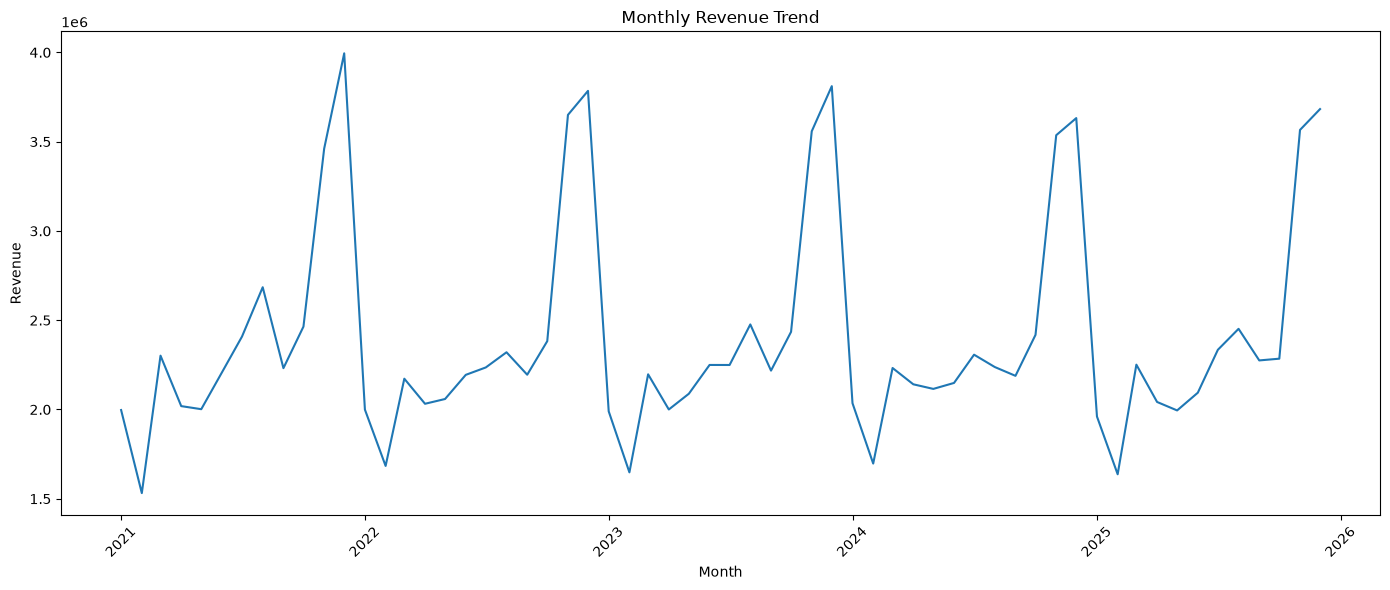

In [124]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly['order_date'],
    monthly['revenue']
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Revenue is strongly seasonal. A stable baseline of about 2.0–2.4M per month rises to about 3.5–4.0M every November and December, and the pattern repeats almost identically in all five years. There is no visible long-term growth: baseline months and peaks in 2025 look like those in 2021.

### Profit Trend

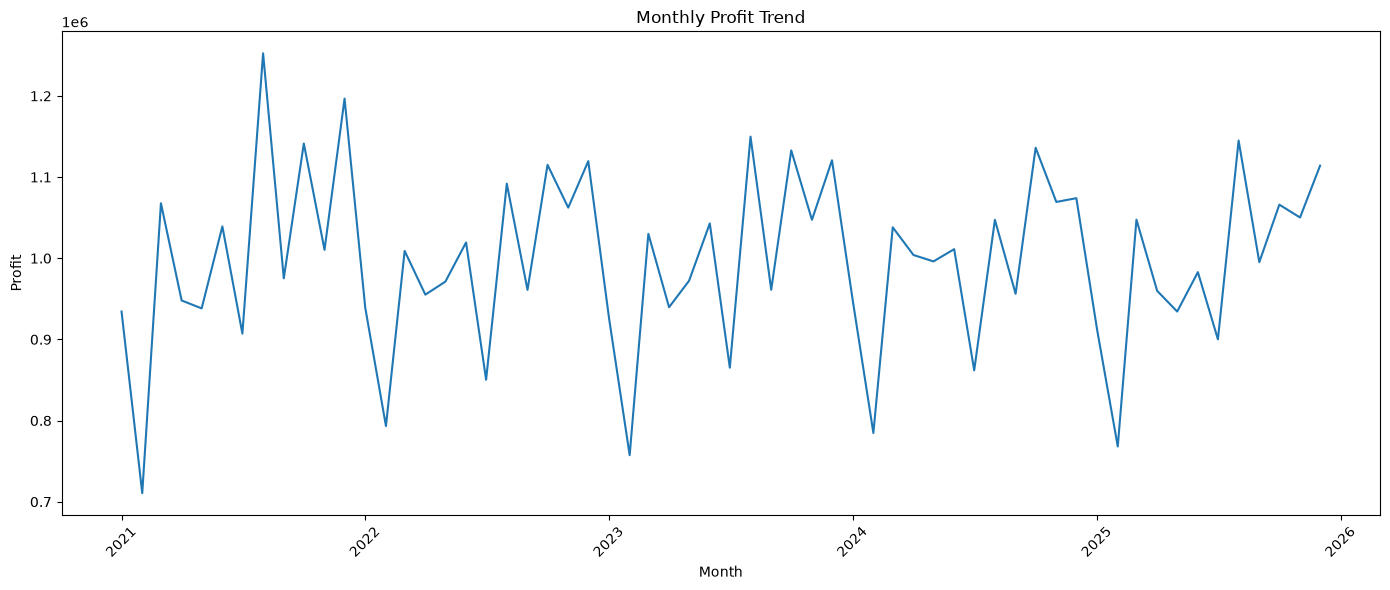

In [125]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly['order_date'],
    monthly['profit']
)

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Profit does not follow revenue. It stays between roughly 0.8M and 1.25M per month, with only a mild rise in peak months, and dips in February each year when revenue is lowest.

### REVENUE + PROFIT

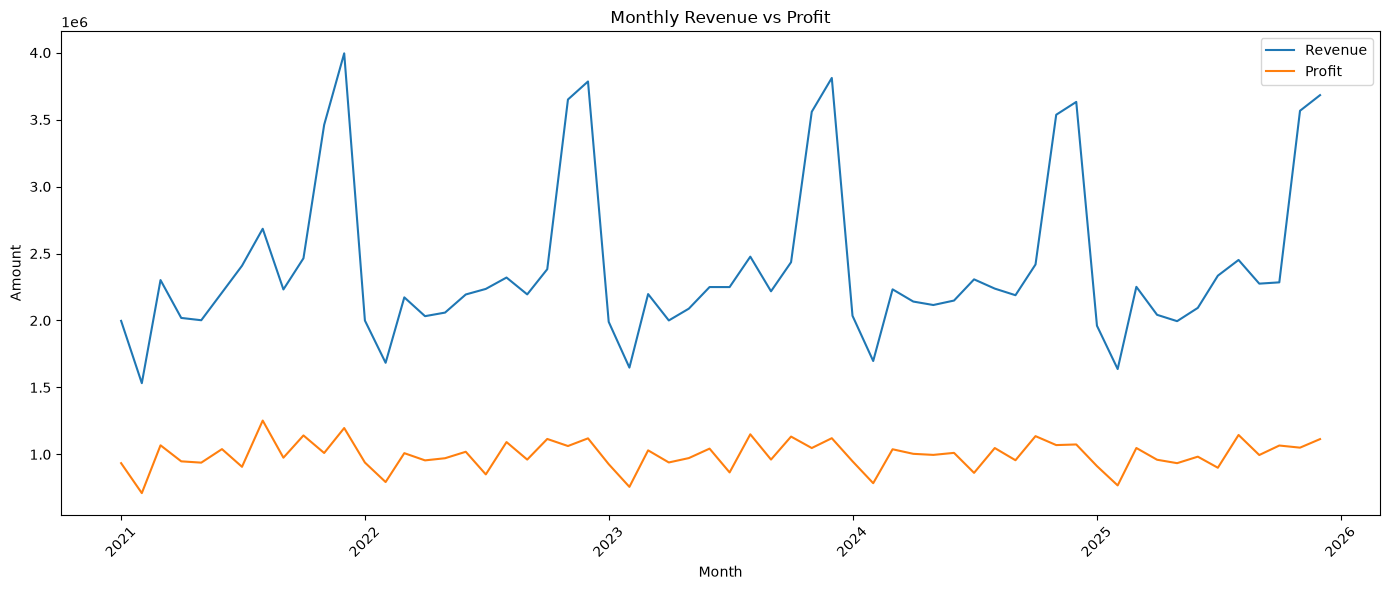

In [126]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly['order_date'],
    monthly['revenue'],
    label='Revenue'
)

plt.plot(
    monthly['order_date'],
    monthly['profit'],
    label='Profit'
)

plt.title('Monthly Revenue vs Profit')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: The gap between the two lines widens every November–December. Peak-season revenue is about 60–75% above a normal month, but profit is close to a normal month. Extra volume in peak season is being sold at near-zero incremental margin.

### Monthly Profit Margin

In [127]:
monthly['profit_margin'] = (
    monthly['profit'] /
    monthly['revenue'] *
    100
)

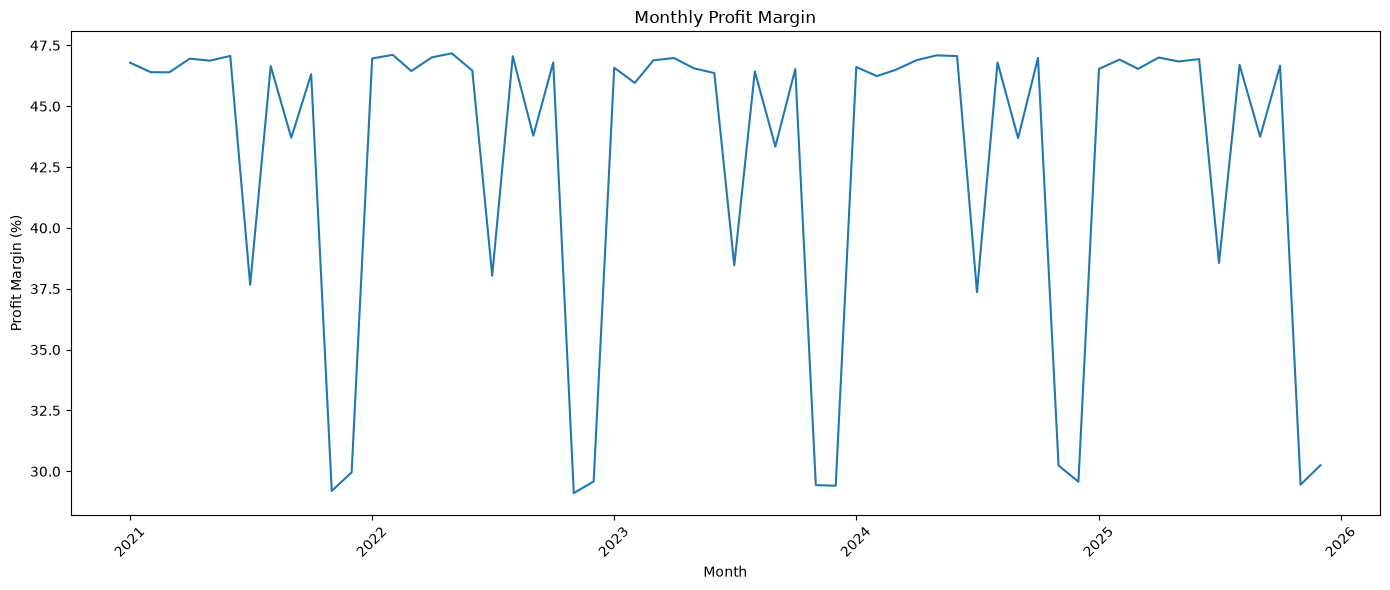

In [128]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly['order_date'],
    monthly['profit_margin']
)

plt.title('Monthly Profit Margin')
plt.xlabel('Month')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Margin is stable at about 46–47% in regular months but drops in a recurring pattern: about 37–38% in July, about 44% in September and about 29–30% in November and December, every year from 2021 to 2025. The repeating timing points to calendar-driven promotions with deeper discounts (see Part C1 to confirm).

### Category Analysis

In [129]:
merged_df = pd.merge(df_orders_clean, df_products_clean, on='product_id', how='inner')
final_df = pd.merge(merged_df, completed_df_sales_customers, on='order_id', how='inner')


for col in ['quantity', 'gross_sales', 'discount_amount', 'tax_amount',
            'shipping_cost', 'net_sales', 'profit']:
    final_df[f'{col}_y'] = final_df[f'{col}_x']


final_df['profit_margin'] = np.where(
    final_df['net_sales_x'] != 0,
    final_df['profit_x'] * 100 / final_df['net_sales_x'],
    np.nan
)
final_df['product_cost'] = final_df['product_cost_x']

final_df['is_realized_loss'] = final_df['is_realized_loss'] & ~final_df['order_id'].duplicated()

print(round(final_df['net_sales_y'].sum(), 2), round(total_revenue, 2))

156796214.64 144195838.5


Insight (reconciliation): Revenue calculated from order lines for Completed orders is 156.8M versus 144.2M from order headers, a difference of 8.7% (profit differs by 9.0%). Category, product and discount-line figures below are therefore on the line basis and are not directly comparable with the headline KPIs. Shares and margins are still reliable because the gap is systematic.

In [130]:
category_analysis = final_df.groupby('product_category').agg(
    orders=('order_id', 'nunique'),
    revenue=('net_sales_x', 'sum'),
    profit=('profit_x', 'sum'),
    avg_order_value=('net_sales_x', 'mean')
).reset_index()

In [131]:
category_analysis['profit_margin'] = (
    category_analysis['profit'] /
    category_analysis['revenue'] *
    100
)

REVENUE

In [132]:
category_analysis.sort_values(
    'revenue',
    ascending=False
)

,product_category,orders,revenue,profit,avg_order_value,profit_margin
4,Electronics,19899,3.348676e+07,1.091160e+07,1545.019979,32.584829
10,Jewelry,17734,2.079554e+07,8.146114e+06,1087.405394,39.172405
9,Home Appliances,19918,2.029504e+07,8.097581e+06,934.695402,39.899308
0,Automotive,20561,1.335020e+07,5.058479e+06,593.184251,37.890651
13,Sports & Outdoors,22816,1.279921e+07,5.704263e+06,508.308464,44.567319
8,Home & Kitchen,17860,8.954936e+06,4.126379e+06,464.877547,46.079376
1,Baby & Kids,19375,7.964048e+06,3.861446e+06,377.908702,48.485968
7,Health & Wellness,21766,7.522138e+06,3.374176e+06,313.331029,44.856606
11,Office Supplies,20415,7.235944e+06,3.650996e+06,324.278192,50.456387
5,Fashion,17562,6.088272e+06,2.931407e+06,321.365628,48.148428


PROFIT

In [133]:
category_analysis.sort_values(
    'profit',
    ascending=False
)

,product_category,orders,revenue,profit,avg_order_value,profit_margin
4,Electronics,19899,3.348676e+07,1.091160e+07,1545.019979,32.584829
10,Jewelry,17734,2.079554e+07,8.146114e+06,1087.405394,39.172405
9,Home Appliances,19918,2.029504e+07,8.097581e+06,934.695402,39.899308
13,Sports & Outdoors,22816,1.279921e+07,5.704263e+06,508.308464,44.567319
0,Automotive,20561,1.335020e+07,5.058479e+06,593.184251,37.890651
8,Home & Kitchen,17860,8.954936e+06,4.126379e+06,464.877547,46.079376
1,Baby & Kids,19375,7.964048e+06,3.861446e+06,377.908702,48.485968
11,Office Supplies,20415,7.235944e+06,3.650996e+06,324.278192,50.456387
7,Health & Wellness,21766,7.522138e+06,3.374176e+06,313.331029,44.856606
5,Fashion,17562,6.088272e+06,2.931407e+06,321.365628,48.148428


PROFIT MARGIN

In [134]:
category_analysis.sort_values(
    'profit_margin',
    ascending=False
)

,product_category,orders,revenue,profit,avg_order_value,profit_margin
6,Grocery,19966,2.445832e+06,1.323088e+06,112.452027,54.095632
2,Beauty & Personal Care,21139,3.864780e+06,1.979176e+06,166.995628,51.210581
3,Books & Media,21899,2.308653e+06,1.175063e+06,95.985919,50.898217
11,Office Supplies,20415,7.235944e+06,3.650996e+06,324.278192,50.456387
14,Toys & Games,19981,4.478318e+06,2.241404e+06,205.805065,50.050120
12,Pet Supplies,18897,5.206537e+06,2.582909e+06,253.692792,49.608962
1,Baby & Kids,19375,7.964048e+06,3.861446e+06,377.908702,48.485968
5,Fashion,17562,6.088272e+06,2.931407e+06,321.365628,48.148428
8,Home & Kitchen,17860,8.954936e+06,4.126379e+06,464.877547,46.079376
7,Health & Wellness,21766,7.522138e+06,3.374176e+06,313.331029,44.856606


Insight: Revenue is concentrated in a few categories: Electronics 33.5M (21.4%), Jewelry 20.8M (13.3%) and Home Appliances 20.3M (12.9%) together generate 47.6% of revenue but only 41.7% of profit. Margin ranges from 32.6% (Electronics) to 54.1% (Grocery), a spread of 21.5 points. Margin falls as ticket size rises: the four categories with the highest revenue per order (Electronics, Jewelry, Home Appliances, Automotive) all earn below 40%, while every category under 400 per order earns 48% or more. Growth in big-ticket categories therefore dilutes company margin.

CATEGORY REVENUE

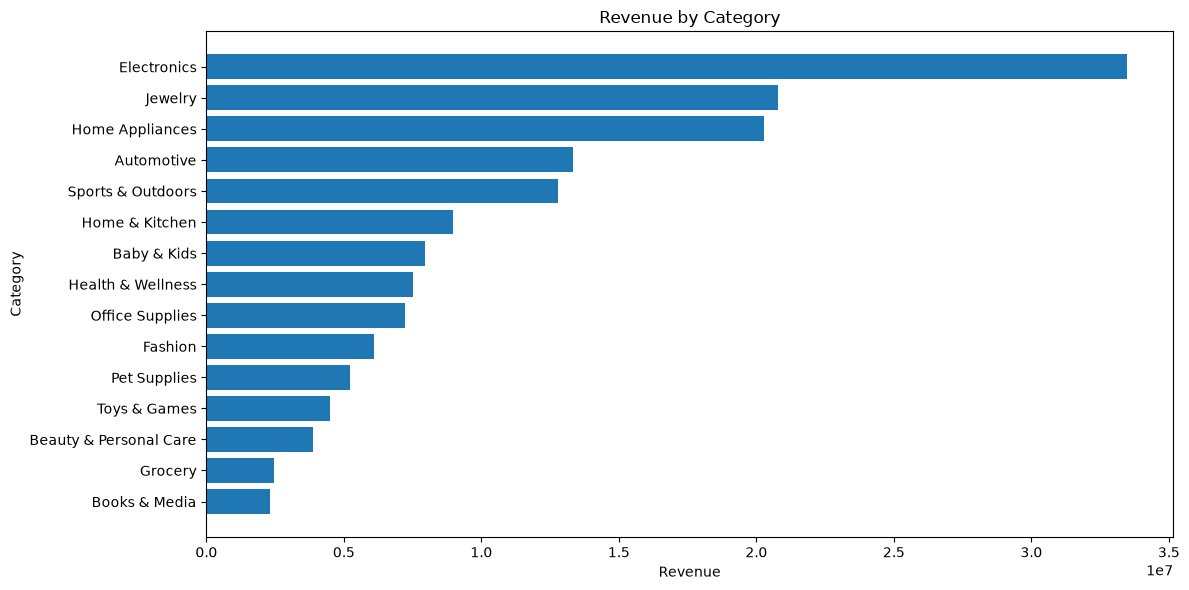

In [135]:
plt.figure(figsize=(12, 6))

category_sorted = category_analysis.sort_values(
    'revenue',
    ascending=True
)

plt.barh(
    category_sorted['product_category'],
    category_sorted['revenue']
)

plt.title('Revenue by Category')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

CATEGORY PROFIT

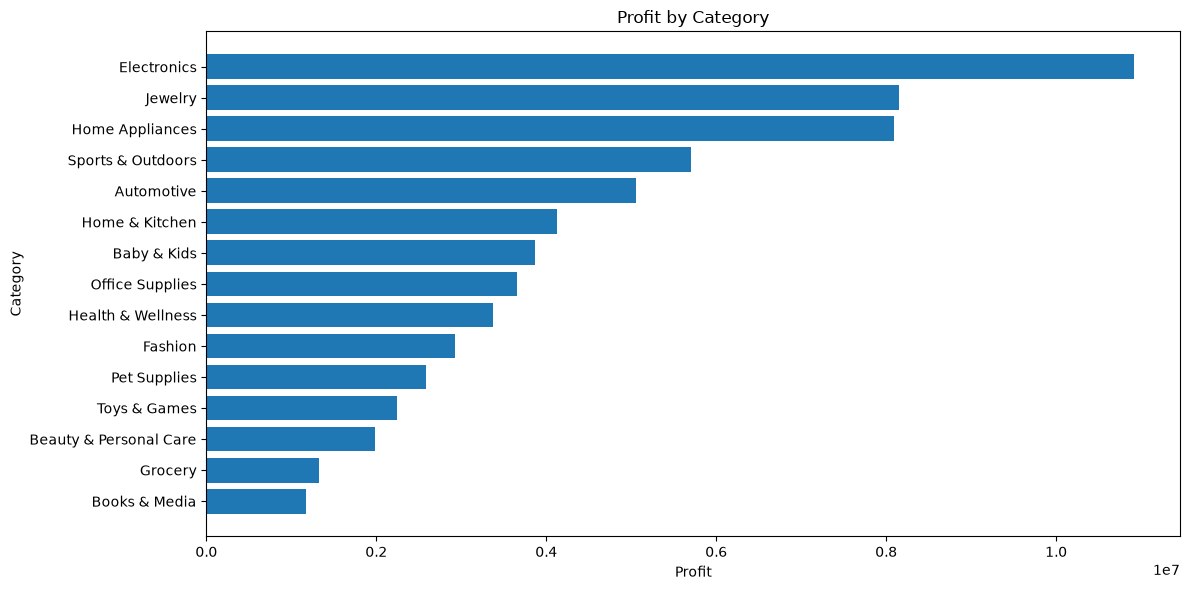

In [136]:
plt.figure(figsize=(12, 6))

category_sorted = category_analysis.sort_values('profit', ascending=True)

plt.barh(category_sorted['product_category'], category_sorted['profit'])

plt.title('Profit by Category')
plt.xlabel('Profit')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### Subcategory Analysis

In [137]:
subcategory_analysis = (
    final_df
    .groupby(['product_category', 'product_subcategory'])
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('net_sales_x', 'sum'),
        profit=('profit_x', 'sum')
    )
    .reset_index()
)

In [138]:
subcategory_analysis['profit_margin'] = (
    subcategory_analysis['profit'] /
    subcategory_analysis['revenue'] *
    100
)

THE HIGHEST REVENUE

In [139]:
subcategory_analysis.sort_values(
    'revenue',
    ascending=False
).head(15)

,product_category,product_subcategory,orders,revenue,profit,profit_margin
37,Electronics,Smartphones,4200,6.288255e+06,2.155209e+06,34.273564
38,Electronics,TVs,3592,5.732863e+06,1.824234e+06,31.820651
36,Electronics,Smart Watches,3441,5.207072e+06,1.659471e+06,31.869561
86,Jewelry,Rings,4141,4.228937e+06,1.654400e+06,39.120951
39,Electronics,Tablets,2483,3.748830e+06,1.140464e+06,30.421855
77,Home Appliances,Toasters,3658,3.659835e+06,1.651388e+06,45.121926
80,Jewelry,Bracelets,3031,3.659783e+06,1.235588e+06,33.761252
73,Home Appliances,Blenders,3033,3.532634e+06,1.446188e+06,40.937946
82,Jewelry,Earrings,2724,3.277171e+06,1.389748e+06,42.406942
33,Electronics,Gaming Consoles,1662,3.250088e+06,1.113258e+06,34.253156


THE HIGHEST PROFIT

In [140]:
subcategory_analysis.sort_values(
    'profit',
    ascending=False
).head(15)

,product_category,product_subcategory,orders,revenue,profit,profit_margin
37,Electronics,Smartphones,4200,6.288255e+06,2.155209e+06,34.273564
38,Electronics,TVs,3592,5.732863e+06,1.824234e+06,31.820651
36,Electronics,Smart Watches,3441,5.207072e+06,1.659471e+06,31.869561
86,Jewelry,Rings,4141,4.228937e+06,1.654400e+06,39.120951
77,Home Appliances,Toasters,3658,3.659835e+06,1.651388e+06,45.121926
73,Home Appliances,Blenders,3033,3.532634e+06,1.446188e+06,40.937946
82,Jewelry,Earrings,2724,3.277171e+06,1.389748e+06,42.406942
80,Jewelry,Bracelets,3031,3.659783e+06,1.235588e+06,33.761252
39,Electronics,Tablets,2483,3.748830e+06,1.140464e+06,30.421855
79,Home Appliances,Washing Machines,2251,2.826905e+06,1.132637e+06,40.066312


THE HIGHEST MARGIN

In [141]:
subcategory_analysis.sort_values('profit_margin', ascending=False).head(15)

,product_category,product_subcategory,orders,revenue,profit,profit_margin
55,Grocery,Snacks,1362,2.064510e+05,125399.459945,60.740544
41,Fashion,Bags,4146,1.277542e+06,724226.599746,56.689071
17,Beauty & Personal Care,Deodorants,2451,4.616514e+05,259532.789878,56.218345
97,Pet Supplies,Bird Cages,2523,5.892078e+05,329719.679892,55.959833
49,Grocery,Dairy,1366,2.047610e+05,112792.629957,55.085013
50,Grocery,Frozen Foods,4157,4.708964e+05,258985.689991,54.998446
51,Grocery,Meat,3299,3.643470e+05,200286.980037,54.971488
52,Grocery,Organic,1930,2.736402e+05,148398.859968,54.231385
91,Office Supplies,Paper Products,3531,1.109500e+06,599685.039875,54.050046
54,Grocery,Produce,3851,4.222583e+05,228024.319836,54.001148


Insight: Smartphones (6.3M), TVs (5.7M) and Smart Watches (5.2M) lead revenue but earn only 32–34%. The lowest-margin subcategories are Tablets (30.4%), Headphones (31.2%), TVs (31.8%) and Smart Watches (31.9%). The highest margins are Grocery Snacks (60.7%), Fashion Bags (56.7%), Deodorants (56.2%) and Bird Cages (56.0%). Bags stands out by combining 56.7% margin with 1.3M revenue, making it a candidate to promote.

### Product Analysis

In [142]:
product_analysis = (
    final_df
    .groupby(['product_id', 'product_name'])
    .agg(
        orders=('order_id', 'nunique'),
        quantity=('quantity_x', 'sum'),
        revenue=('net_sales_x', 'sum'),
        profit=('profit_x', 'sum')
    )
    .reset_index()
)

In [143]:
product_analysis['profit_margin'] = (
    product_analysis['profit'] /
    product_analysis['revenue'] *
    100
)

TOP PROFIT PRODUCTS

In [144]:
product_analysis.sort_values(
    'profit',
    ascending=False
).head(20)

,product_id,product_name,orders,quantity,revenue,profit,profit_margin
995,PROD-000996,Messika Networked disintermediate knowledge us...,302,672,576195.039551,303341.990623,52.645714
61,PROD-000062,OnePlus Adaptive uniform success Gaming Consoles,277,620,744579.590820,283973.850595,38.138817
50,PROD-000051,HP Versatile actuating budgetary management Sm...,280,600,738325.519531,282126.439625,38.211660
55,PROD-000056,HP Function-based neutral access Cameras,269,598,701172.060303,264969.680740,37.789538
3,PROD-000004,Sony Customer-focused systematic support Smart...,292,643,626745.331543,260939.499874,41.634056
951,PROD-000952,Mikimoto Monitored zero administration website...,291,607,500943.180847,257479.799572,51.399003
64,PROD-000065,Xiaomi Self-enabling exuding productivity Gami...,289,640,807673.911743,255577.079926,31.643597
1002,PROD-001003,Tous Diverse impactful software Chains,268,565,463825.329407,254037.599827,54.770101
4,PROD-000005,OnePlus Quality-focused background parallelism...,250,540,617996.461182,240547.090401,38.923700
76,PROD-000077,OnePlus Switchable methodical neural-net TVs,300,627,775751.649414,239411.100423,30.861823


Insight: The top profit contributors are electronics and premium jewelry. PROD-000996 (Messika jewelry) leads with 303K profit at a 52.6% margin, while top electronics products earn 30–38%. Jewelry margin is uneven: the top jewelry products earn above 50% while the category average is 39.2%, so product selection within Jewelry matters.

LOSS-MAKING PRODUCTS

In [145]:
loss_products = product_analysis[
    product_analysis['profit'] < 0
].sort_values(
    'profit'
)

loss_products.head(20)

,product_id,product_name,orders,quantity,revenue,profit,profit_margin


Insight: No product is loss-making in aggregate. The losses seen in the data come from individual orders with extreme discounts, not from specific products, so the fix is discount control, not delisting products.

### REVENUE VS PROFT - PRODUCT LEVEL

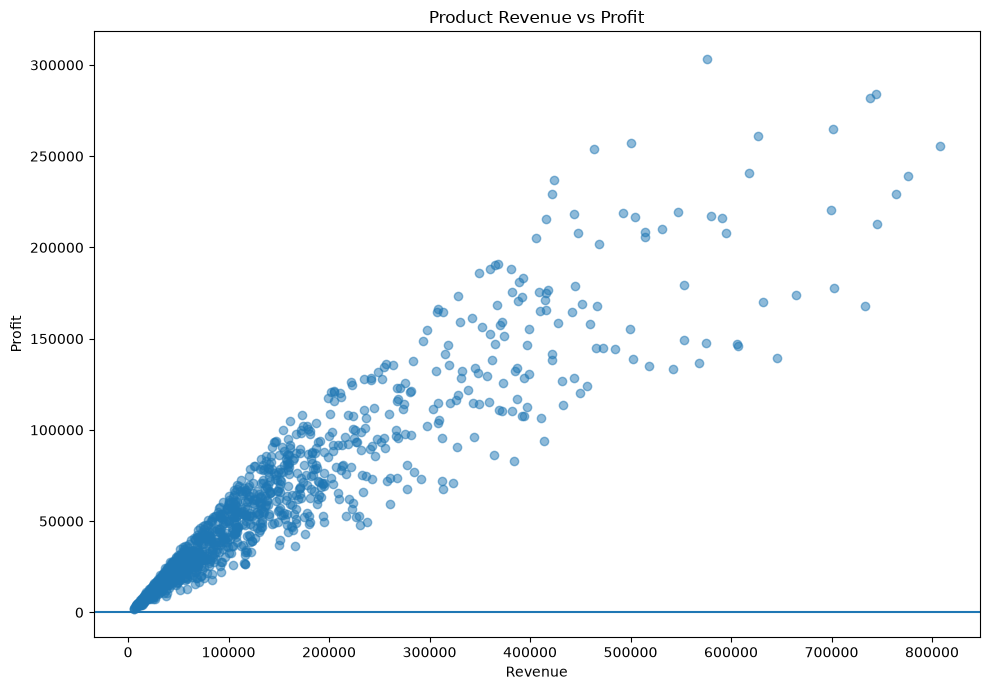

In [146]:
plt.figure(figsize=(10, 7))

plt.scatter(
    product_analysis['revenue'],
    product_analysis['profit'],
    alpha=0.5
)

plt.axhline(0)

plt.title('Product Revenue vs Profit')
plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

Insight: Profit rises almost linearly with revenue, but the spread widens above 200K revenue: at the same revenue, some products earn about 50K and others about 150K. These wide gaps identify products whose margin is well below peers and are the best targets for price or discount review.

### PRODUCT PROFITABILITY MATRIX

In [147]:
revenue_median = product_analysis['revenue'].median()
profit_median = product_analysis['profit'].median()

In [148]:
def classify_product(row):

    if row['revenue'] >= revenue_median and row['profit'] >= profit_median:
        return 'High Revenue / High Profit'

    elif row['revenue'] >= revenue_median and row['profit'] < profit_median:
        return 'High Revenue / Low Profit'

    elif row['revenue'] < revenue_median and row['profit'] >= profit_median:
        return 'Low Revenue / High Profit'

    else:
        return 'Low Revenue / Low Profit'

In [149]:
product_analysis['profitability_segment'] = (
    product_analysis.apply(
        classify_product,
        axis=1
    )
)

In [150]:
product_analysis[
    'profitability_segment'
].value_counts()

profitability_segment
High Revenue / High Profit    550
Low Revenue / Low Profit      549
High Revenue / Low Profit      38
Low Revenue / High Profit      38
Name: count, dtype: int64

Insight: 550 products are high revenue / high profit and 549 are low / low. The 38 high revenue / low profit products are the priority watch list: they take shelf space and discount budget but contribute less profit than expected. Because revenue and profit are highly correlated, a revenue vs margin split (Part C notes) separates products better than revenue vs profit.

### CUSTOMER ANALYSIS

In [151]:
customer_analysis = (
    final_df
    .groupby('customer_id')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('net_sales_x', 'sum'),
        profit=('profit_x', 'sum'),
        quantity=('quantity_x', 'sum')
    )
    .reset_index()
)

In [152]:
customer_analysis['profit_margin'] = (
    customer_analysis['profit'] /
    customer_analysis['revenue'] *
    100
)

THE MOST VALUABLE CUSTOMER

In [153]:
customer_analysis.sort_values(
    'revenue',
    ascending=False
).head(20)

,customer_id,orders,revenue,profit,quantity,profit_margin
11671,CUST-011800,11,33274.459820,14955.760062,114,44.946665
9230,CUST-009330,13,32884.830011,15061.970012,115,45.802183
18039,CUST-018228,11,30245.789974,10329.859932,110,34.153051
17070,CUST-017251,14,29674.689822,10616.649964,117,35.776785
9586,CUST-009693,7,29058.390362,10970.250031,87,37.752435
12732,CUST-012869,12,27848.310049,10912.540086,87,39.185646
2942,CUST-002969,13,27003.849638,9962.620033,85,36.893332
796,CUST-000802,10,26742.780090,11824.390003,78,44.215261
13025,CUST-013167,12,26707.210030,9431.900007,97,35.315932
5814,CUST-005878,8,26358.999771,10881.069843,87,41.280284


FOR PROFIT

In [154]:
customer_analysis.sort_values(
    'profit',
    ascending=False
).head(20)

,customer_id,orders,revenue,profit,quantity,profit_margin
9230,CUST-009330,13,32884.830011,15061.970012,115,45.802183
11671,CUST-011800,11,33274.459820,14955.760062,114,44.946665
796,CUST-000802,10,26742.780090,11824.390003,78,44.215261
17479,CUST-017665,7,24469.829742,11717.300114,45,47.884682
16872,CUST-017052,9,23590.669971,11498.570038,63,48.742024
7720,CUST-007805,13,25186.529863,11426.690011,96,45.368259
12132,CUST-012262,10,23579.460045,11367.020149,73,48.207296
15065,CUST-015231,7,25914.680082,11352.619952,66,43.807679
24208,CUST-024455,7,24548.290077,11312.719978,80,46.083536
1731,CUST-001747,14,25174.469978,11309.939922,90,44.926229


Insight: There is no customer concentration. The largest customer contributes 33.3K (about 0.02% of revenue) with 11 orders and a 44.9% margin, and the top 20 all sit between 21K and 33K. The business depends on its broad base of about 24.7K customers, not on key accounts.

LOSS-MAKING CUSTOMERS

In [155]:
customer_analysis[
    customer_analysis['profit'] < 0
].sort_values(
    'profit'
).head(20)

,customer_id,orders,revenue,profit,quantity,profit_margin
12743,CUST-012880,2,7666.359886,-1070.310020,16,-13.961124
4056,CUST-004099,2,2524.250036,-575.069996,17,-22.781816
22423,CUST-022651,2,3126.220062,-516.220016,12,-16.512594
19534,CUST-019732,2,2761.980080,-505.140018,15,-18.289054
24020,CUST-024266,2,5497.430054,-501.140034,26,-9.115897
18529,CUST-018720,3,4682.070095,-460.789985,13,-9.841587
2908,CUST-002934,2,4171.680121,-430.800008,15,-10.326775
10210,CUST-010322,2,2756.909992,-420.490027,18,-15.252222
1431,CUST-001443,4,3908.529919,-411.709982,22,-10.533627
24483,CUST-024731,2,2648.209890,-353.659997,11,-13.354682


Insight: Only a small group of customers is unprofitable, and the worst loses 1,070 on 7.7K revenue. These customers typically have 1–5 orders and negative margins of −4% to −23%, consistent with heavy-discount purchases rather than a customer type.

### CUSTOMER SEGMENT ANALYSIS

In [156]:
segment_analysis = (
    final_df
    .groupby('customer_segment')
    .agg(
        customers=('customer_id', 'nunique'),
        orders=('order_id', 'nunique'),
        revenue=('net_sales_x', 'sum'),
        profit=('profit_x', 'sum')
    )
    .reset_index()
)

In [157]:
segment_analysis['profit_margin'] = (
    segment_analysis['profit'] /
    segment_analysis['revenue'] *
    100
)

In [158]:
segment_analysis

,customer_segment,customers,orders,revenue,profit,profit_margin
0,Business,2494,11298,1.570418e+07,6.684101e+06,42.562556
1,Consumer,13508,62211,8.627455e+07,3.685919e+07,42.723132
2,Premium,6230,28544,3.901736e+07,1.537379e+07,39.402423
3,VIP,2516,11506,1.580012e+07,6.247009e+06,39.537721


Insight: Segments are almost identical in behaviour: every segment spends about 6.3K and places about 4.6 orders per customer (Consumer 6,387 / Premium 6,263 / VIP 6,280 / Business 6,297). Consumer is 55% of revenue only because it has the most customers. Premium (39.4%) and VIP (39.5%) earn about 3 points less margin than Consumer (42.7%) and Business (42.6%), consistent with heavier discounting. The VIP label does not identify more valuable customers, so a behavioural segmentation (RFM, Part C7) is needed.

### Geographic Analysis

In [159]:
region_analysis = (
    final_df
    .groupby('region')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('net_sales_x', 'sum'),
        profit=('profit_x', 'sum')
    )
    .reset_index()
)

In [160]:
region_analysis['profit_margin'] = (
    region_analysis['profit'] /
    region_analysis['revenue'] *
    100
)

REVENUE

In [161]:
region_analysis.sort_values(
    'revenue',
    ascending=False
)

,region,orders,revenue,profit,profit_margin
3,South,36205,4.932155e+07,2.004372e+07,40.638864
0,Central,24259,3.279914e+07,1.329366e+07,40.530523
4,West,21621,3.081878e+07,1.339582e+07,43.466414
1,East,17841,2.400873e+07,9.604067e+06,40.002400
2,North,13633,1.984802e+07,8.826819e+06,44.472046


PROFIT

In [162]:
region_analysis.sort_values(
    'profit',
    ascending=False
)

,region,orders,revenue,profit,profit_margin
3,South,36205,4.932155e+07,2.004372e+07,40.638864
4,West,21621,3.081878e+07,1.339582e+07,43.466414
0,Central,24259,3.279914e+07,1.329366e+07,40.530523
1,East,17841,2.400873e+07,9.604067e+06,40.002400
2,North,13633,1.984802e+07,8.826819e+06,44.472046


Insight: South is the largest region (49.3M, 31.5% of revenue) but earns a below-average 40.6% margin. North (44.5%) and West (43.5%) are the most profitable; East (40.0%) and Central (40.5%) the least. Revenue per customer is similar everywhere (6.1–6.6K), so regional size follows customer count and the 4.5-point margin spread is the real regional difference.

### DISCOUNT ANALYSIS

In [163]:
final_df['discount_band'].value_counts()

discount_band
LOW DISCOUNT       276192
MEDIUM DISCOUNT     46680
HIGH DISCOUNT        4156
Name: count, dtype: int64

In [164]:
discount_analysis = (
    final_df
    .groupby('discount_band', observed=True)
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('net_sales_x', 'sum'),
        profit=('profit_x', 'sum')
    )
    .reset_index()
)

In [165]:
discount_analysis['profit_margin'] = (
    discount_analysis['profit'] /
    discount_analysis['revenue'] *
    100
)

In [166]:
discount_analysis

,discount_band,orders,revenue,profit,profit_margin
0,HIGH DISCOUNT,1630,1.717693e+06,3.142291e+04,1.829367
1,LOW DISCOUNT,96266,1.313404e+08,5.890887e+07,44.852058
2,MEDIUM DISCOUNT,15663,2.373812e+07,6.223789e+06,26.218544


Insight: 84.8% of Completed orders (96,266) sit in the LOW band and earn a 44.9% margin on 131.3M. The MEDIUM band (15,663 orders, 13.8%) earns 26.2% and the HIGH band (1,630 orders, 1.4%) earns 1.8%. Deeper discounts cut margin sharply: a 30–50% discount costs about 19 margin points compared with the LOW band.

### DISCOUNT VS LOSS RATE

In [167]:
discount_analysis['loss_orders'] = (
    final_df
    .groupby('discount_band', observed=True)['is_realized_loss']
    .sum()
    .values
)

In [168]:
discount_analysis['loss_rate'] = (
    discount_analysis['loss_orders'] /
    discount_analysis['orders'] *
    100
)

DISCOUNT ANALYSIS

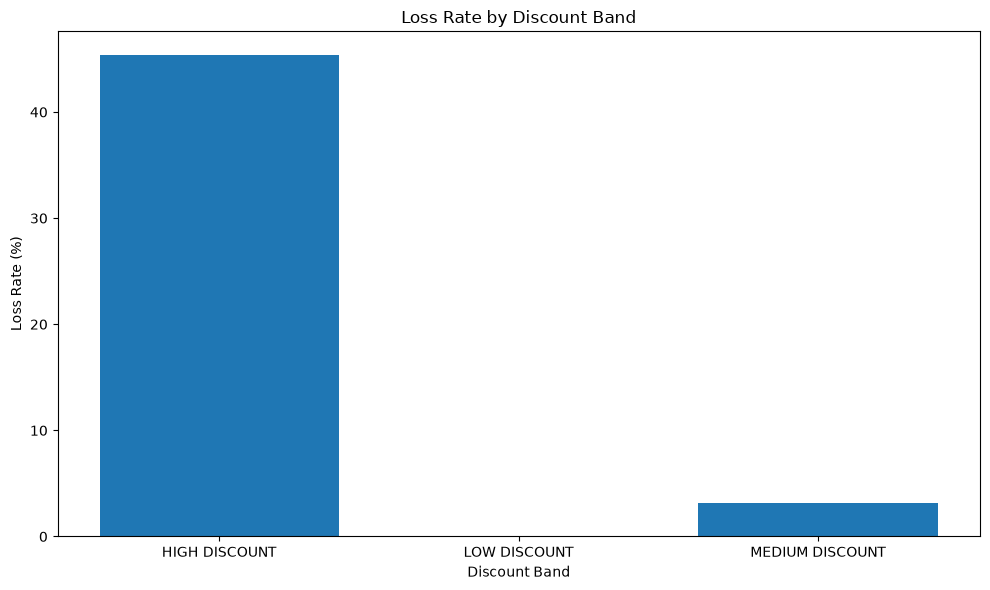

In [169]:
plt.figure(figsize=(10, 6))

plt.bar(
    discount_analysis['discount_band'].astype(str),
    discount_analysis['loss_rate']
)

plt.title('Loss Rate by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Loss Rate (%)')
plt.tight_layout()
plt.show()

Insight: Losses begin only above 30% discount. The LOW band has no loss-making orders, the MEDIUM band 3.1% (490 orders), and the HIGH band 45.3% (739 orders). In the SQL five-band view the loss rate is 0.3% at 30–40%, 8.6% at 40–50%, 44.3% at 50–60% and 59.8% above 60%, which supports a hard cap at 40%.

### PARETO ANALYSIS

In [170]:
pareto = product_analysis.sort_values(
    'revenue',
    ascending=False
).copy()

In [171]:
pareto['cumulative_revenue'] = (
    pareto['revenue'].cumsum()
)

In [172]:
pareto['cumulative_revenue_pct'] = (
    pareto['cumulative_revenue'] /
    pareto['revenue'].sum()
    * 100
)

In [173]:
products_for_80 = pareto[
    pareto['cumulative_revenue_pct'] <= 80
]

In [174]:
products_for_80.shape[0] / pareto.shape[0] * 100

45.276595744680854

PARETO PROFIT

In [175]:
profit_pareto = product_analysis.sort_values(
    'profit',
    ascending=False
).copy()

In [176]:
profit_pareto['cumulative_profit'] = (
    profit_pareto['profit'].cumsum()
)

In [177]:
profit_pareto['cumulative_profit_pct'] = (
    profit_pareto['cumulative_profit'] /
    profit_pareto['profit'].sum()
    * 100
)

Insight: 45.3% of products (about 532 of 1,175) are needed to reach 80% of revenue, so revenue is broadly distributed and there is no classic 80/20 dependence on a few products. Assortment risk is low, but it also means there is no small group of hero products that can carry the business.

### NEGATIV PROFIT ANALYSIS

In [178]:
realized_losses = completed_df_sales_customers[completed_df_sales_customers['profit'] < 0]

In [179]:
print("Loss-making orders:", realized_losses['order_id'].nunique())
print("Total loss:", realized_losses['profit'].sum())

Loss-making orders: 1229
Total loss: -191127.65968200006


In [180]:
loss_rate = (
    realized_losses['order_id'].nunique() /
    final_df['order_id'].nunique()
    * 100
)

print(f"Loss rate: {loss_rate:.2f}%")

Loss rate: 1.08%


Insight: 1,229 Completed orders lose money, a total of 191K (a loss rate of 1.08% of Completed orders and only 0.3% of profit). Label this clearly: the SQL figure of 0.94% (1,296 orders) uses all statuses as the denominator. The direct loss is small; the larger cost is margin dilution, estimated at about 5.2M (Part C2).

### DISCOUNT BAND for REALIZED LOSS

In [181]:
loss_by_discount = (
    final_df
    .groupby('discount_band', observed=True)
    .agg(
        total_orders=('order_id', 'nunique'),
        loss_orders=('is_realized_loss', 'sum')
    )
    .reset_index()
)

In [182]:
loss_by_discount['loss_rate'] = (
    loss_by_discount['loss_orders'] /
    loss_by_discount['total_orders'] *
    100
)

In [183]:
loss_by_discount

,discount_band,total_orders,loss_orders,loss_rate
0,HIGH DISCOUNT,1630,739,45.337423
1,LOW DISCOUNT,96266,0,0.000000
2,MEDIUM DISCOUNT,15663,490,3.128392


Insight: Every loss-making Completed order has a discount above 30%: 739 are in the HIGH band and 490 in the MEDIUM band. Orders at or below a 30% discount never lose money, which makes 30% the safe zone and 40% a sensible hard limit.

### CORRELATION ANALYSIS

In [184]:
final_df.columns

Index(['order_id', 'product_id', 'quantity_x', 'unit_price_x',
       'discount_percentage', 'discount_amount_x', 'gross_sales_x',
       'tax_amount_x', 'shipping_cost_x', 'net_sales_x', 'product_cost_x',
       'profit_x', 'product_name', 'product_category', 'product_subcategory',
       'brand', 'supplier', 'unit_price_y', 'product_cost_y', 'product_rating',
       'order_date', 'order_time', 'order_status', 'sales_channel',
       'customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_type', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code', 'payment_method',
       'payment_status', 'currency', 'shipping_method', 'warehouse',
       'delivery_days', 'estimated_delivery_days', 'delivery_status',
       'return_status', 'return_reason', 'customer_rating', 'review_sentiment',
       'customer_review', 'marketing_channel', 'campaign_name', 'coupon_code',
       'loyalty_points_earned', 'loyalty_points

In [185]:
corr_cols = [
    'quantity_x',
    'gross_sales_x',
    'discount_amount_x',
    'tax_amount_x',
    'shipping_cost_x',
    'net_sales_x',
    'product_cost',
    'profit_y',
    'profit_margin'
]

In [186]:
correlation = final_df[corr_cols].corr()

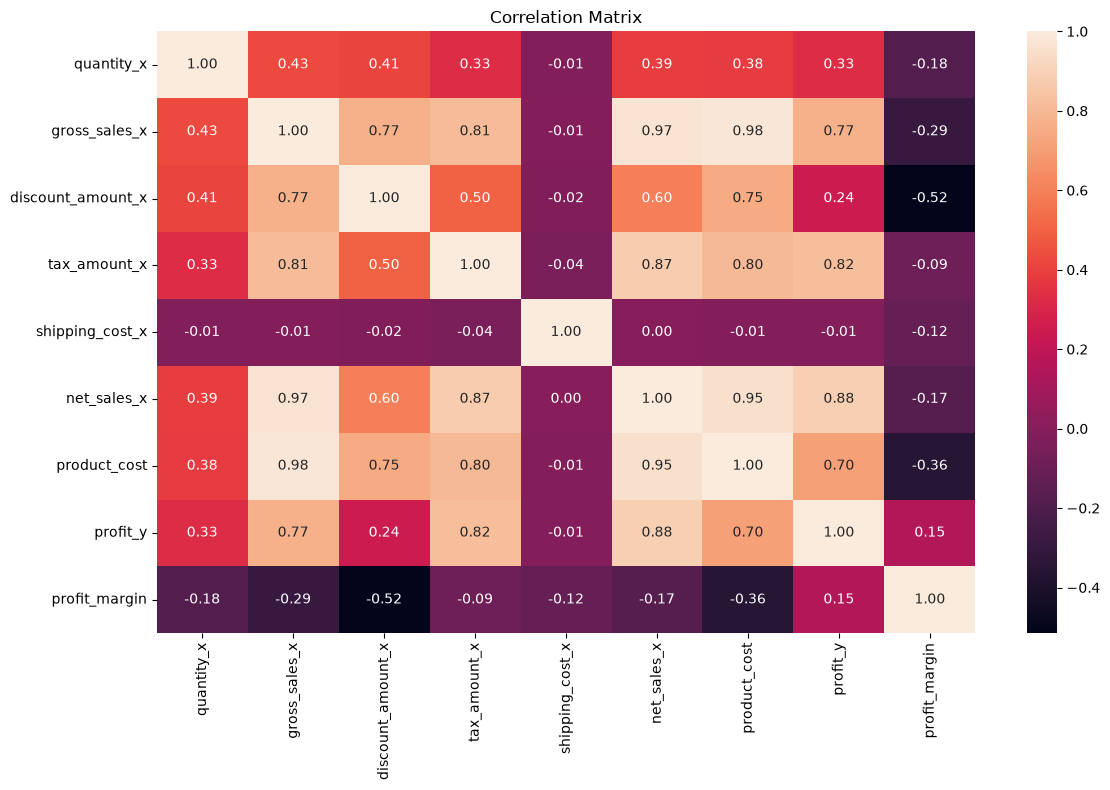

In [187]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Insight: Discount amount has the strongest negative link with profit margin (−0.52), followed by product cost (−0.36) and gross sales (−0.29). Discount amount correlates positively with profit (0.24) only because larger orders carry larger absolute discounts, so discount percentage, not discount amount, should be the control variable. Shipping cost is uncorrelated with every metric (about 0), so it is not a profit driver. Gross sales, net sales and product cost move together (0.95–0.98), which is expected for a fixed-markup catalog.

### SHIPPING COST ANALYSIS

In [188]:
shipping_analysis = (
    final_df
    .groupby('region')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('net_sales_x', 'sum'),
        shipping=('shipping_cost_x', 'sum'),
        profit=('profit_y', 'sum')
    )
    .reset_index()
)

In [189]:
shipping_analysis['shipping_ratio'] = (
    shipping_analysis['shipping'] /
    shipping_analysis['revenue'] *
    100
)

In [190]:
shipping_analysis.sort_values(
    'shipping_ratio',
    ascending=False
)

,region,orders,revenue,shipping,profit,shipping_ratio
1,East,17841,2.400873e+07,458648.189950,9.604067e+06,1.910339
0,Central,24259,3.279914e+07,596060.760146,1.329366e+07,1.817306
3,South,36205,4.932155e+07,894531.990192,2.004372e+07,1.813674
4,West,21621,3.081878e+07,492866.330027,1.339582e+07,1.599240
2,North,13633,1.984802e+07,307497.010000,8.826819e+06,1.549258


Insight: Shipping costs 1.55–1.91% of revenue in every region. East (1.91%) and Central (1.82%) are highest, North (1.55%) and West (1.60%) lowest. The spread is under 0.4 points, so shipping optimization is a minor lever compared with discounting.

In [191]:
summary = pd.DataFrame({
    'Metric': [
        'Revenue',
        'Profit',
        'Profit Margin',
        'Orders',
        'Customers',
        'Average Order Value',
        'Loss-making Orders',
        'Loss Rate',
        'Average Discount '
    ],
    
    'Value': [
        total_revenue,
        total_profit,
        profit_margin,
        total_orders,
        total_customers,
        aov,
        realized_losses['order_id'].nunique(),
        loss_rate,
        discount_pct.mean()
    ]
})

summary

,Metric,Value
0,Revenue,1.441958e+08
1,Profit,5.975847e+07
2,Profit Margin,4.144258e+01
3,Orders,1.135590e+05
4,Customers,2.474800e+04
5,Average Order Value,1.269788e+03
6,Loss-making Orders,1.229000e+03
7,Loss Rate,1.082257e+00
8,Average Discount,1.511709e+01


Insight: Shipping costs 1.55–1.91% of revenue in every region. East (1.91%) and Central (1.82%) are highest, North (1.55%) and West (1.60%) lowest. The spread is under 0.4 points, so shipping optimization is a minor lever compared with discounting.

In [192]:
import os

os.makedirs('data/processed', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

In [193]:
monthly.to_csv(
    'outputs/monthly_analysis.csv',
    index=False
)

category_analysis.to_csv(
    'outputs/category_analysis.csv',
    index=False
)

product_analysis.to_csv(
    'outputs/product_analysis.csv',
    index=False
)

customer_analysis.to_csv(
    'outputs/customer_analysis.csv',
    index=False
)

discount_analysis.to_csv(
    'outputs/discount_analysis.csv',
    index=False
)

region_analysis.to_csv(
    'outputs/region_analysis.csv',
    index=False
)

loss_by_discount.to_csv(
    'outputs/loss_by_discount.csv',
    index=False
)

In [194]:
c = completed_df_sales_customers.copy()
c['discount_pct'] = c['discount_amount'] / c['gross_sales'] * 100
by_month = (c.groupby('OrderDate_Month')
    .agg(revenue=('net_sales','sum'), profit=('profit','sum'),
         avg_discount=('discount_pct','mean'), orders=('order_id','nunique'),
         loss_orders=('profit', lambda s: (s < 0).sum()))
    .assign(margin=lambda d: d.profit / d.revenue * 100,
            loss_share=lambda d: d.loss_orders / d.loss_orders.sum() * 100))
by_month.round(1)

,revenue,profit,avg_discount,orders,loss_orders,margin,loss_share
OrderDate_Month,,,,,,,
1,9981860.1,4661149.2,11.1,7967,0,46.7,0.0
2,8197789.0,3814136.5,11.2,6614,0,46.5,0.0
3,11154475.2,5192492.0,11.2,8919,0,46.6,0.0
4,10234258.1,4806705.4,11.1,8315,0,47.0,0.0
5,10258785.4,4812122.2,11.1,8408,0,46.9,0.0
6,10894300.5,5095667.7,11.1,8930,0,46.8,0.0
7,11534663.7,4384662.3,22.9,8415,13,38.0,1.1
8,12171403.3,5686498.4,11.2,9890,0,46.7,0.0
9,11107322.6,4848831.1,15.8,8904,0,43.7,0.0


Insight: Average discount rises from 11.1% in regular months to 31.7% in November–December, while 98.9% of all loss-making orders occur during these two peak-season months. Despite November–December generating the highest revenue levels, profitability margins fall sharply to around 29.5–29.8%, compared with approximately 46–47% in regular months. This indicates a strong association between peak-season discounting and the recurring year-end margin deterioration, suggesting that discount strategy should be closely monitored during the holiday period.


Conclusions and Recommendations
Key findings
1. Revenue of 144.2M and profit of 59.8M (41.44% margin) are healthy, but revenue is seasonal and shows no visible long-term growth.
2. Peak-season revenue (Nov–Dec, about 25% of the year) produces almost no extra profit: margin falls from about 46–47% to about 29–30%.
3. Discounts above 30% drive all losses; the 30–50% band earns 26.2% margin versus 44.9% below 30%. Margin leakage is about 5.2M (8.6% of profit) against a direct loss of only 191K.
4. Electronics is 21.4% of revenue at a 32.6% margin; the three biggest categories deliver 47.6% of revenue but 41.7% of profit.
5. Customer segments are behaviourally identical, and 18.6% of booked order value is cancelled, pending or returned. Recommendations
6. Cap discounts at 40% and require approval from 30%. 2. Replace blanket Nov–Dec discounts with targeted bundles. 3. Manage Electronics margin through bundling and discount depth. 4. Build RFM segments. 5. Analyse returns and cancellations. Limitations: header vs line totals differ by 8.7%; currencies are not converted; profit includes tax; the dataset appears simulated.